In [168]:
import matplotlib.pyplot as plt
import shap
from catboost import Pool
#from catboost.utils import get_tree_plot
import numpy as np
from catboost_cv import PhotoZCatBoostPipeline
from catboost import CatBoostRegressor, Pool
import scienceplots
import pandas as pd
plt.style.use(['science', 'notebook', 'grid'])  # Use the science plots style
import shap
from astropy.table import Table,vstack,join,unique
import fitsio
from astropy.coordinates import SkyCoord
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from Metrics import PhotoZMetrics
import astropy.units as u
shap.initjs()


In [169]:
# cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/ZHOUETAL/config_catboost.yaml')
# cv_pipe = PhotoZCatBoostPipeline(feature_names=cfg['features'])
# DR1, legacy = cv_pipe.load_astronomical_data(cfg)
# legacy = cv_pipe.compute_magnitudes(legacy)
# legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1, feature_names = cfg['features'])
# X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered)

cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/logs/config_used.yaml')
cv_pipe = PhotoZCatBoostPipeline(feature_names=cfg['features'])
DR1, legacy = cv_pipe.load_astronomical_data(cfg)
legacy = cv_pipe.compute_magnitudes(legacy)
legacy_filtered, DR1_filtered = cv_pipe.filter_data(legacy, DR1, feature_names = cfg['features'])
X, y = cv_pipe.prepare_ml_data(legacy_filtered, DR1_filtered)





INFO:catboost_cv:Config loaded from /user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/logs/config_used.yaml
INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Loading astronomical data...
INFO:catboost_cv:Loading data for the region: north
INFO:catboost_cv:Data loaded in 2.39 seconds
INFO:catboost_cv:Computing magnitudes and colors...
/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_cv.py:207: RuntimeWarning: invalid value encountered in divide
  legacy['MODEL_WEIGHT'] = legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])    #(p = dchi2dev/(dchi2dev+dchi2exp))
INFO:catboost_cv:Applying data quality cuts...


Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'Z_PHOT_MEAN', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'Z_SPEC', 'SURVEY', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', 'MAG_W2W3', 'MAG_W1W3', 'MAG_RW1', 'MAG_RW2', 'MAG_RW3', 'MAG_G

INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3']
INFO:catboost_cv:Filtered from 1858728 to 1306929 objects
INFO:catboost_cv:Filtered from 1858728 to 1305941 objects for unique TARGETID
INFO:catboost_cv:Feature matrix shape: (1305941, 18)
INFO:catboost_cv:Target range: [0.010, 0.500]


In [171]:
modelsouth = CatBoostRegressor() 
modelsouth.load_model("/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_south/models/catboost_south_noweight.cbm")
modelnorth =  CatBoostRegressor() 
modelnorth.load_model("/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/models/catboost_north_noweight.cbm")

In [ ]:
# cv_pipe.load_pretrained_model('/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_south_noweight_1773740706.cbm')
# cv_pipe.evaluate_model(False)


INFO:catboost_cv:Loading model from /user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_south_noweight_1773740706.cbm
INFO:catboost_cv:Loaded model with 9000 iterations
INFO:catboost_cv:Evaluating model performance...



MODEL EVALUATION RESULTS

TEST SET METRICS:
------------------------------
MAE:  0.022137
MSE:  0.001055
RMSE: 0.032479
R²:   0.905329

CUSTOM PHOTOZ METRICS (TEST):
{'bias': 3.193818908371873e-05, 'sigma': 0.02598274970768132, 'sigma_NMAD': 0.017990461487046278, 'delta(0.3)': 0.9999797119091094, 'outlier_fraction(0.15)': 0.0012822073442889023}

VALIDATION SET METRICS:
------------------------------
MAE:  0.022216
MSE:  0.001056
RMSE: 0.032496
R²:   0.905548

CUSTOM PHOTOZ METRICS (VALIDATION):
{'bias': -2.5017608717688093e-05, 'sigma': 0.026013177251563113, 'sigma_NMAD': 0.01808453209004898, 'delta(0.3)': 0.9999857983363766, 'outlier_fraction(0.15)': 0.0012091702170825725}

PERFORMANCE COMPARISON:
------------------------------
Test RMSE:       0.032479
Validation RMSE: 0.032496
Difference:      0.000017
✅ Consistent performance across datasets


{'test': {'mae': 0.02213721206001045,
  'mse': 0.0010548768475643702,
  'rmse': 0.032478867707547474,
  'r2': 0.9053294933823832,
  'photoz': <Metrics.PhotoZMetrics at 0x74540dc782b0>},
 'validation': {'mae': 0.022215595909472436,
  'mse': 0.001055978469869934,
  'rmse': 0.032495822344878945,
  'r2': 0.9055484189749202,
  'photoz': <Metrics.PhotoZMetrics at 0x74540dc794e0>}}

In [82]:
explainer = shap.TreeExplainer(modelnorth)

In [83]:
sample_idx = np.random.choice(len(X_test), 10000, replace=False)
X_sample = X_test[sample_idx]


In [84]:
shap_values = explainer.shap_values(X_sample)

In [65]:
len(cfg['features']), X.shape

(18, (1305941, 18))

In [66]:
shap.plots.force(explainer.expected_value,shap_values[0, ...])


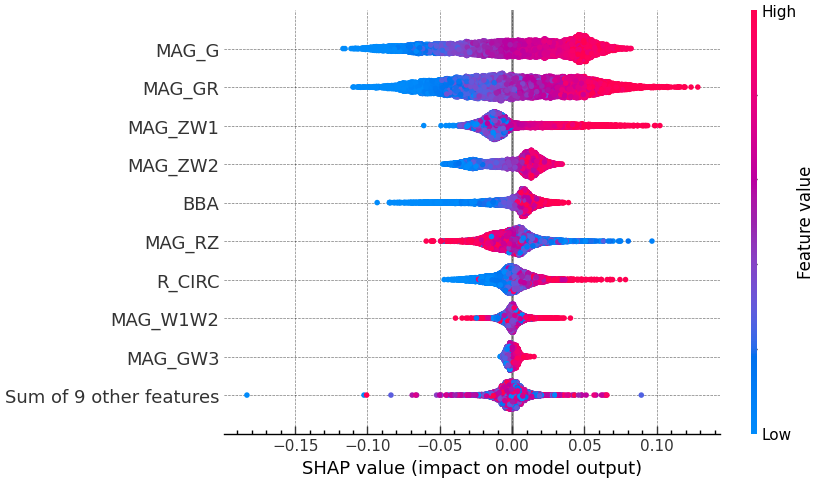

In [85]:
base_values = np.repeat(explainer.expected_value, shap_values.shape[0])

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=base_values,
    data=X_sample,
    feature_names=cfg['features']
)

shap.plots.beeswarm(shap_exp)

In [172]:
north = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_north_unique.fits')[1].read())
south = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_south_unique.fits')[1].read())
DR1_SGC=Table(fitsio.FITS('../desi_dr1_SGC.fits')[1].read())
DR1_NGC=Table(fitsio.FITS('../desi_dr1_NGC.fits')[1].read())
DR1=vstack([DR1_NGC,DR1_SGC])

In [173]:
coords_dr = SkyCoord(ra=DR1['RA']*u.deg, dec=DR1['DEC']*u.deg)
coords_south = SkyCoord(ra=south['RA']*u.deg, dec=south['DEC']*u.deg)
idx, d2d, _ = coords_south.match_to_catalog_sky(coords_dr)
matched_south = south[d2d < 1*u.arcsec]
matched_DR_south = DR1[idx[d2d < 1*u.arcsec]]
coords_north = SkyCoord(ra=north['RA']*u.deg, dec=north['DEC']*u.deg)
idx, d2d, _ = coords_north.match_to_catalog_sky(coords_dr)
matched_north = north[d2d < 1*u.arcsec]
matched_DR_north = DR1[idx[d2d < 1*u.arcsec]]

In [174]:
data_instance = PhotoZCatBoostPipeline(feature_names=cfg['features'])
matched_north = data_instance.compute_magnitudes(matched_north)
matched_north_photoz_filtered,  DR1_north_photoz_filtered= data_instance.filter_data(matched_north, matched_DR_north, feature_names =list(np.hstack([cfg['features'], 'Z_PHOT_MEDIAN'])))
matched_north_filtered, DR1_north_filtered = data_instance.filter_data(matched_north, matched_DR_north, feature_names = cfg['features'])
X_north, y_north = cv_pipe.prepare_ml_data(matched_north_filtered, DR1_north_filtered)


INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Computing magnitudes and colors...
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3', 'Z_PHOT_MEDIAN']
INFO:catboost_cv:Filtered from 37455 to 24285 objects
INFO:catboost_cv:Filtered from 37455 to 24285 objects for unique TARGETID
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3']
INFO:catboost_cv:Filtered from 37455 to 24285 objects
INFO:catboost_cv:Filtered from 37455 to 24285 objects for unique TARGETID
INFO:catboost_cv:Feature matri

Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'R_CIRC', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'FIBERMAG_G', 'FIBERMAG_R', 'FIBERMAG_Z', 'MAG_NOEXT_G', 'MAG_NOEXT_R', 'MAG_NOEXT_Z', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', '

INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Computing magnitudes and colors...
/user/animesh.sah/DESI_PECVEL/ML_photoz/catboost_cv.py:207: RuntimeWarning: invalid value encountered in divide
  legacy['MODEL_WEIGHT'] = legacy['DCHISQ'][:,2]/(legacy['DCHISQ'][:,2]+legacy['DCHISQ'][:,3])    #(p = dchi2dev/(dchi2dev+dchi2exp))
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3']
INFO:catboost_cv:Filtered from 37455 to 24285 objects
INFO:catboost_cv:Filtered from 37455 to 24285 objects for unique TARGETID


Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'R_CIRC', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'FIBERMAG_G', 'FIBERMAG_R', 'FIBERMAG_Z', 'MAG_NOEXT_G', 'MAG_NOEXT_R', 'MAG_NOEXT_Z', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', '

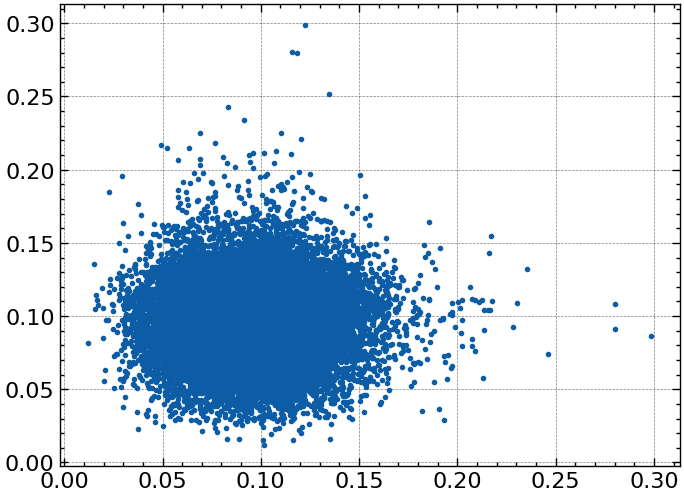

In [142]:
plt.plot(z_perturbed['median'],Z_pred_north,'.')

data_instance = PhotoZCatBoostPipeline(feature_names=cfg['features'])
matched_north_perturbed = data_instance.compute_magnitudes(matched_north)
matched_north_perturbed = data_instance._add_features(matched_north_perturbed)
matched_north_filtered_perturbed, DR1_north_filtered_perturbed = data_instance.filter_data(matched_north_perturbed, matched_DR_north, feature_names = cfg['features'],return_all_columns=True)



In [143]:
Z_pred_north = modelnorth.predict(X_north)
z_perturbed = np.load('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_north/predictions/perturbed_predictions.npz')

In [144]:
valid_legacy

array([ True,  True,  True, ...,  True,  True,  True])

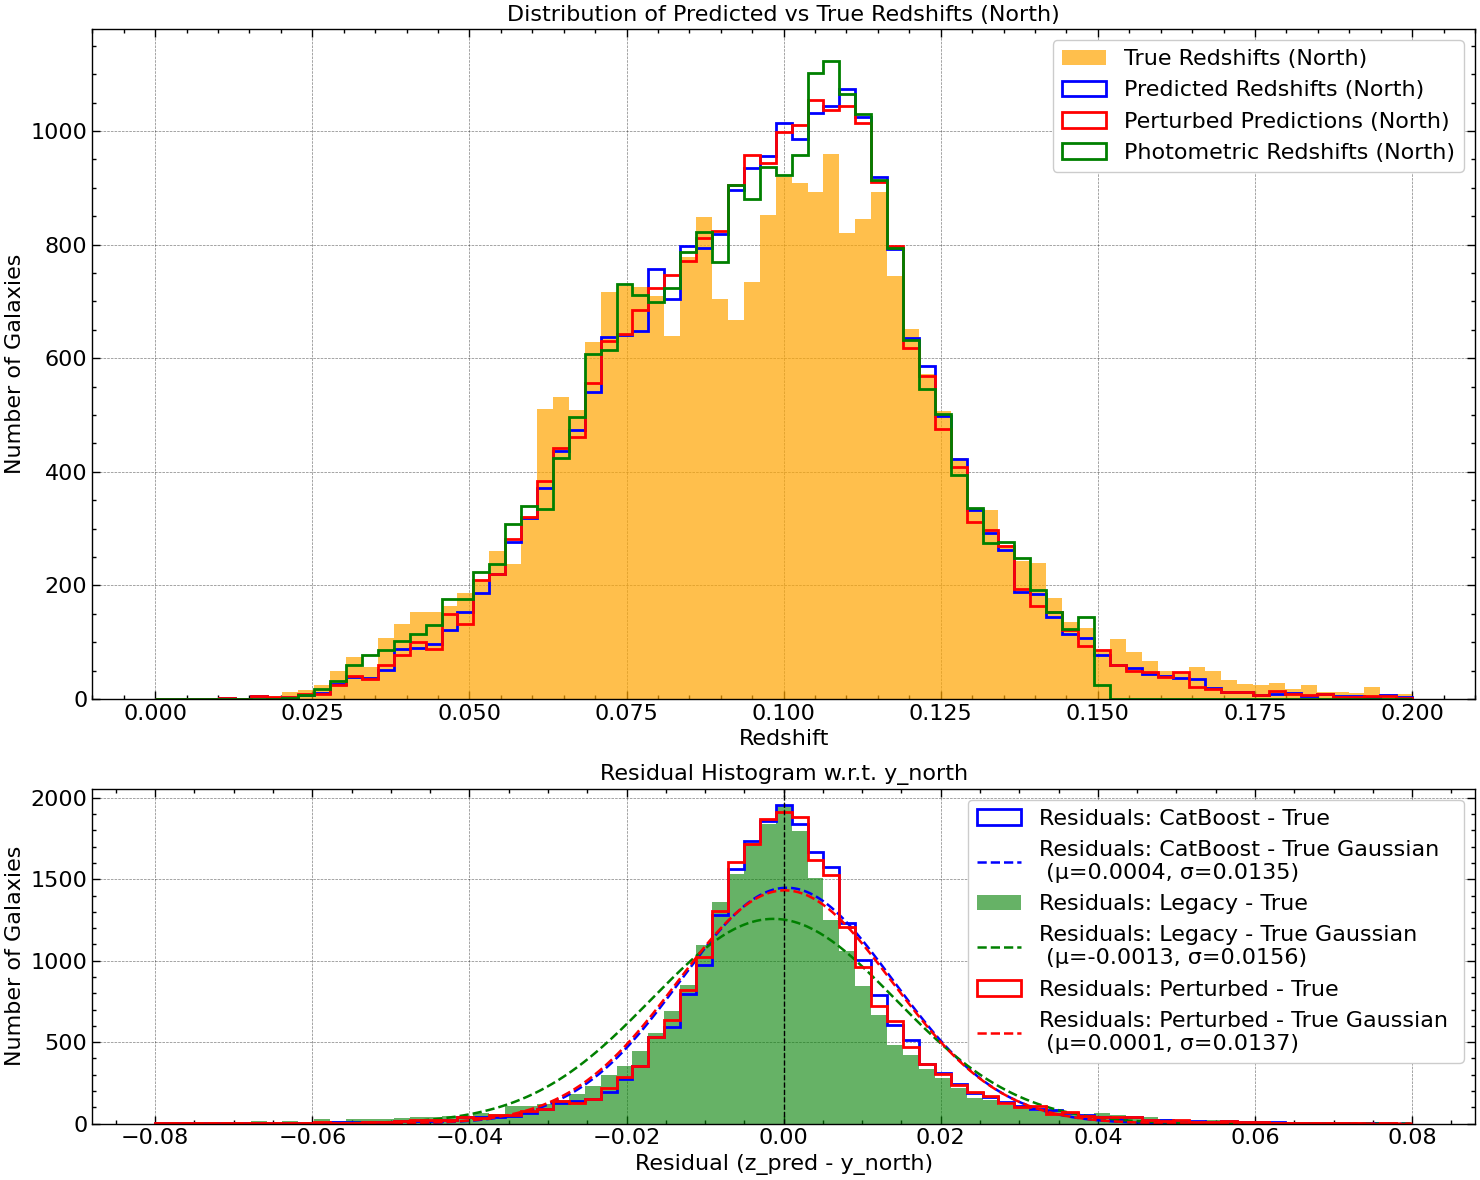

In [145]:
bins = np.linspace(0, 0.2, 80)
res_bins = np.linspace(-0.08, 0.08, 80)

legacy_photoz = np.asarray(matched_north_photoz_filtered['Z_PHOT_MEDIAN'])
valid_legacy = np.ones_like(legacy_photoz, dtype=bool) #np.isfinite(legacy_photoz) & (legacy_photoz > 0)

res_cb = Z_pred_north - y_north
res_legacy = legacy_photoz[valid_legacy] - y_north[valid_legacy]

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(15, 12), gridspec_kw={"height_ratios": [2, 1]}
)
ax0.hist(y_north, bins=bins, alpha=0.7, label='True Redshifts (North)', color='orange')

ax0.hist(Z_pred_north, bins=bins, histtype='step',lw=2, label='Predicted Redshifts (North)', color='blue')
ax0.hist(z_perturbed['median'], bins=bins, histtype='step',lw=2, label='Perturbed Predictions (North)', color='red')
ax0.hist(legacy_photoz[valid_legacy], bins=bins, histtype='step',lw=2, label='Photometric Redshifts (North)', color='green')
ax0.set_xlabel('Redshift')
ax0.set_ylabel('Number of Galaxies')
ax0.set_title('Distribution of Predicted vs True Redshifts (North)')
ax0.legend()

res_perturbed = np.asarray(z_perturbed['median']) - DR1_north_filtered_perturbed['Z']

def _plot_residual_with_gaussian(ax, residuals, bins, color, label, **hist_kwargs):
    r = np.asarray(residuals)
    r = r[np.isfinite(r)]

    ax.hist(r, bins=bins, color=color, label=label, **hist_kwargs)

    # Fit Gaussian in the displayed residual range
    r_fit = r[(r >= bins[0]) & (r <= bins[-1])]
    if r_fit.size < 2:
        return

    mu = r_fit.mean()
    sigma = r_fit.std(ddof=1)
    if sigma <= 0:
        return

    x = np.linspace(bins[0], bins[-1], 400)
    bw = bins[1] - bins[0]
    y = r_fit.size * bw * np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(x, y, '--', color=color, lw=1.8, label=f'{label} Gaussian \n (μ={mu:.4f}, σ={sigma:.4f})')

_plot_residual_with_gaussian(ax1, res_cb, res_bins, 'blue',  'Residuals: CatBoost - True', histtype='step', lw=2)
_plot_residual_with_gaussian(ax1, res_legacy, res_bins, 'green', 'Residuals: Legacy - True', alpha=0.6)
_plot_residual_with_gaussian(ax1, res_perturbed, res_bins, 'red', 'Residuals: Perturbed - True', histtype='step', lw=2)
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Residual (z_pred - y_north)')
ax1.set_ylabel('Number of Galaxies')
ax1.set_title('Residual Histogram w.r.t. y_north')
ax1.legend()

plt.tight_layout()
plt.show()

In [146]:
len(y_north), len(Z_pred_north) , len(matched_north_photoz_filtered['Z_PHOT_MEDIAN'])

(24285, 24285, 24285)

(0.0, 0.15)

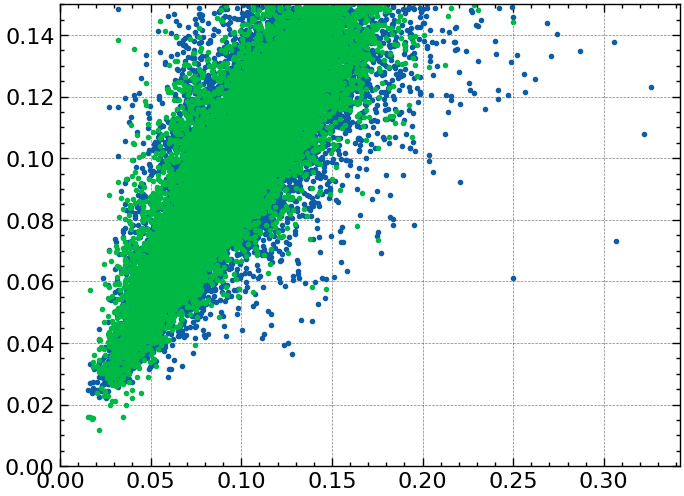

In [166]:
plt.plot(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN'], '.')
plt.plot(y_north,Z_pred_north,'.')
plt.ylim(0,0.15)

In [219]:
DR1_north_photoz_filtered['Z']

0.12056022254961388
0.08226299000673737
0.0720500627309081
0.12251361159539433
0.1898208778459794
0.07990771921237104
0.08969116722501694
0.05290281900803717
0.11337603507365046
0.11746033339233575
0.11575532302896735


In [229]:
np.mean(np.abs(matched_north_photoz_filtered['Z_PHOT_MEDIAN']-DR1_north_photoz_filtered['Z']))


0.019350341967058416

In [218]:
print('MSE for Catboost :',mean_squared_error(y_north,Z_pred_north))
print('MAE for Catboost :',mean_absolute_error(y_north, Z_pred_north))
print('R2 for Catboost :',r2_score(y_north, Z_pred_north))
print('Photo Z metrics')
metric = PhotoZMetrics(y_north, Z_pred_north)
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

print('------------------------------------------------------------')
print('MSE for Legacy :',mean_squared_error(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('MAE for Legacy :',mean_absolute_error(DR1_north_photoz_filtered['Z'],matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('R2 for Legacy :',r2_score(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN']))
print('Photo Z metrics')
metric_legacy = PhotoZMetrics(DR1_north_photoz_filtered['Z'], matched_north_photoz_filtered['Z_PHOT_MEDIAN'])
for key, value in metric_legacy.summary().items():
     print(f"{key} for Legacy: {value}")

MSE for Catboost : 0.00019109574939670348
MAE for Catboost : 0.009805658633284193
R2 for Catboost : 0.7674499544273833
Photo Z metrics
bias for Catboost: -0.0003834986414209204
sigma for Catboost: 0.012488824249488162
sigma_NMAD for Catboost: 0.009522736628423423
delta(0.3) for Catboost: 1.0
outlier_fraction(0.15) for Catboost: 0.0
------------------------------------------------------------
MSE for Legacy : 0.8089961567334999
MAE for Legacy : 0.019350341967058416
R2 for Legacy : -983.4912494404184
Photo Z metrics
bias for Legacy: 0.009774591613526201
sigma for Legacy: 0.8222748836919653
sigma_NMAD for Legacy: 0.010178503607279694
delta(0.3) for Legacy: 0.9999176446366069
outlier_fraction(0.15) for Legacy: 0.0002470660901791229


In [148]:
print('MSE for Catboost :',mean_squared_error(DR1_north_filtered_perturbed['Z'], z_perturbed['median']))
print('MAE for Catboost :',mean_absolute_error(DR1_north_filtered_perturbed['Z'], z_perturbed['median']))
print('R2 for Catboost :',r2_score(DR1_north_filtered_perturbed['Z'], z_perturbed['median']))
print('Photo Z metrics')
metric = PhotoZMetrics(DR1_north_filtered_perturbed['Z'], z_perturbed['median'])
for key, value in metric.summary().items():
     print(f"{key} for Catboost: {value}")

MSE for Catboost : 0.00019552468105141725
MAE for Catboost : 0.009903716212187318
R2 for Catboost : 0.7620602570944475
Photo Z metrics
bias for Catboost: -0.00012346047122378914
sigma for Catboost: 0.012634823081837231
sigma_NMAD for Catboost: 0.009591952528442778
delta(0.3) for Catboost: 1.0
outlier_fraction(0.15) for Catboost: 0.0


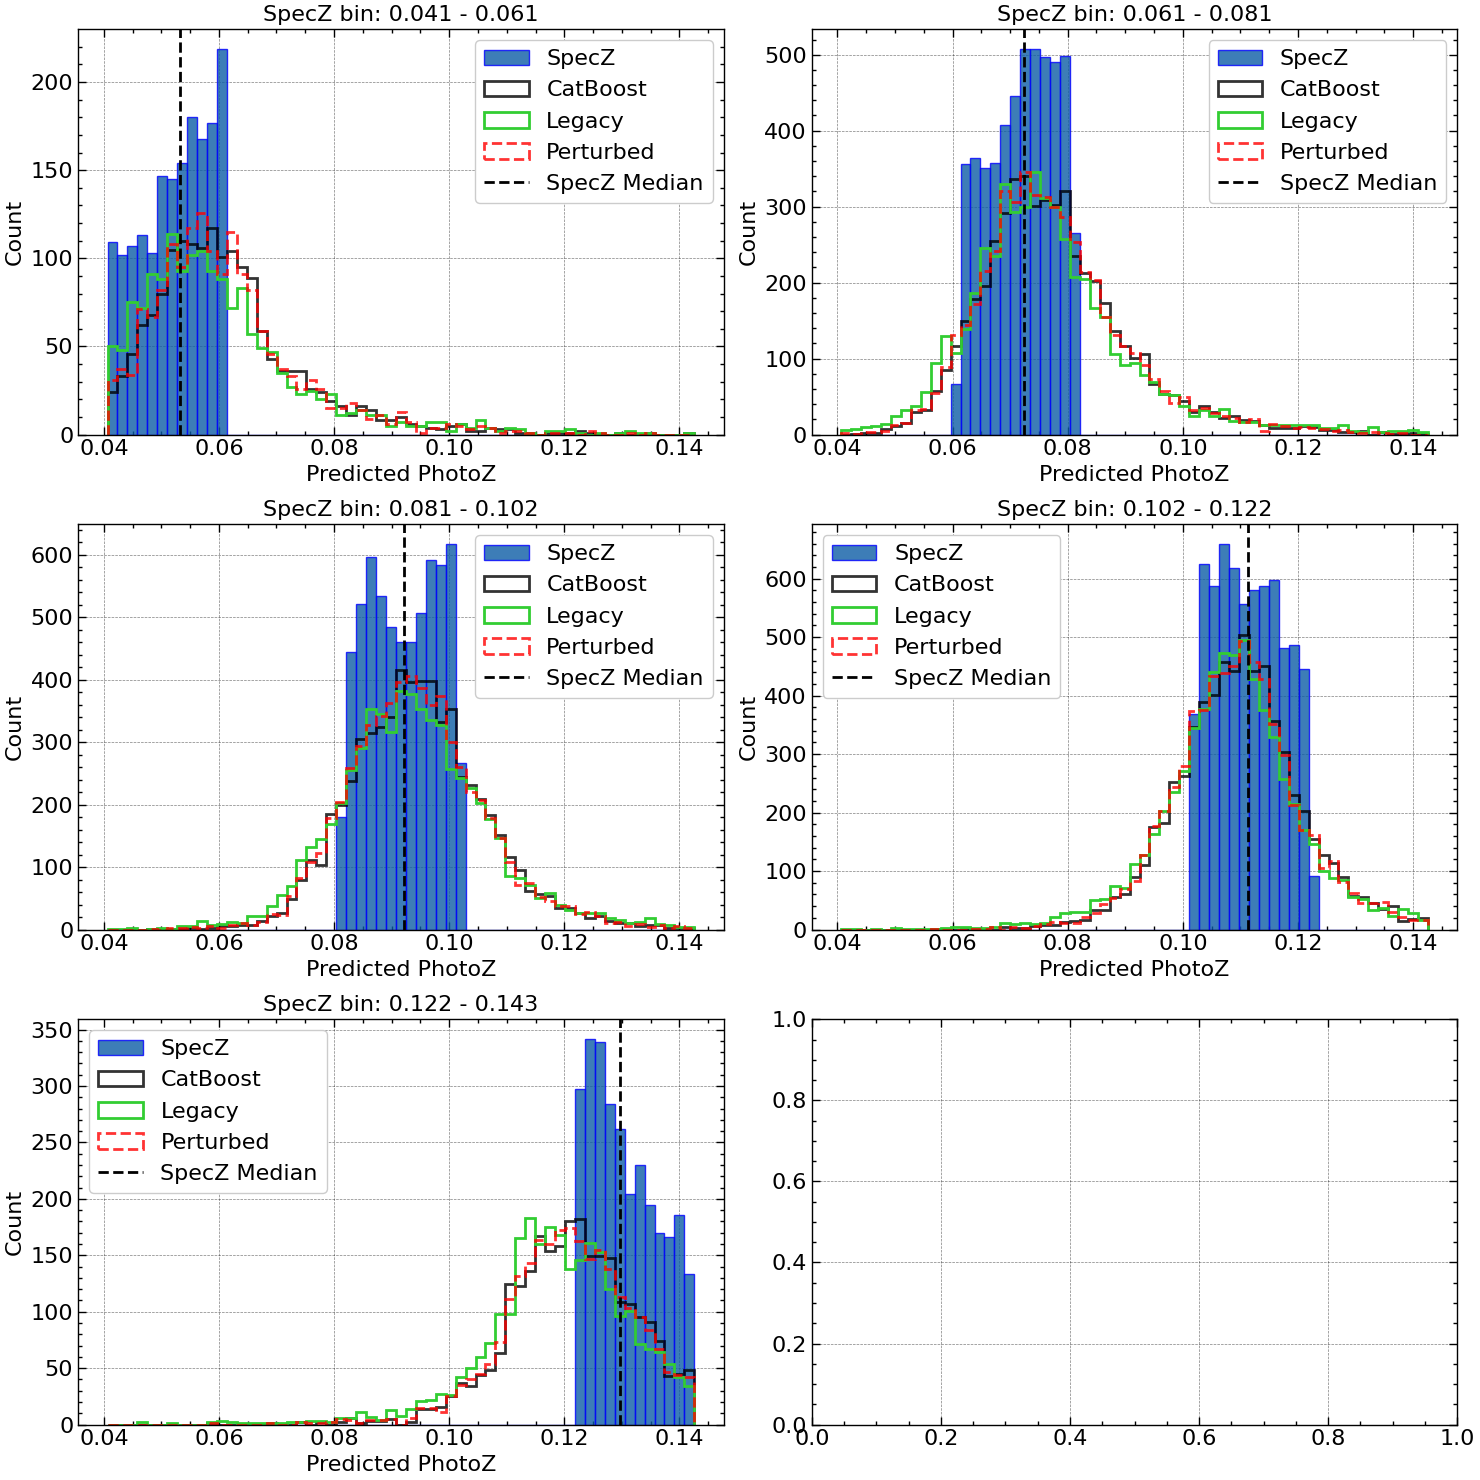

In [154]:
nbins = 5 
zbins = np.linspace(np.percentile(DR1_north_filtered['Z'], 2), np.percentile(DR1_north_filtered['Z'], 95), nbins+1)
bin_indices = np.digitize(DR1_north_filtered['Z'], zbins)
bin_indices_perturbed = np.digitize(DR1_north_filtered_perturbed['Z'], zbins)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    mask_perturbed = bin_indices_perturbed == i
    phot_z_bin  =Z_pred_north[mask]
    spec_z_bin = DR1_north_filtered['Z'][mask]
    phot_z_legacy_bin = matched_north_photoz_filtered['Z_PHOT_MEDIAN'][mask]
    phot_z_perturbed_bin = z_perturbed['median'][mask_perturbed]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.8, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.8, label='CatBoost',histtype='step',edgecolor='k',lw = 2)
    axes[i-1].hist(phot_z_legacy_bin,bins =bin_hist ,alpha =1, label='Legacy',histtype='step',edgecolor='limegreen',lw =2)
    axes[i-1].hist(phot_z_perturbed_bin,bins =bin_hist ,alpha =0.8, label='Perturbed',histtype='step',edgecolor='red',lw =2,ls='--')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()

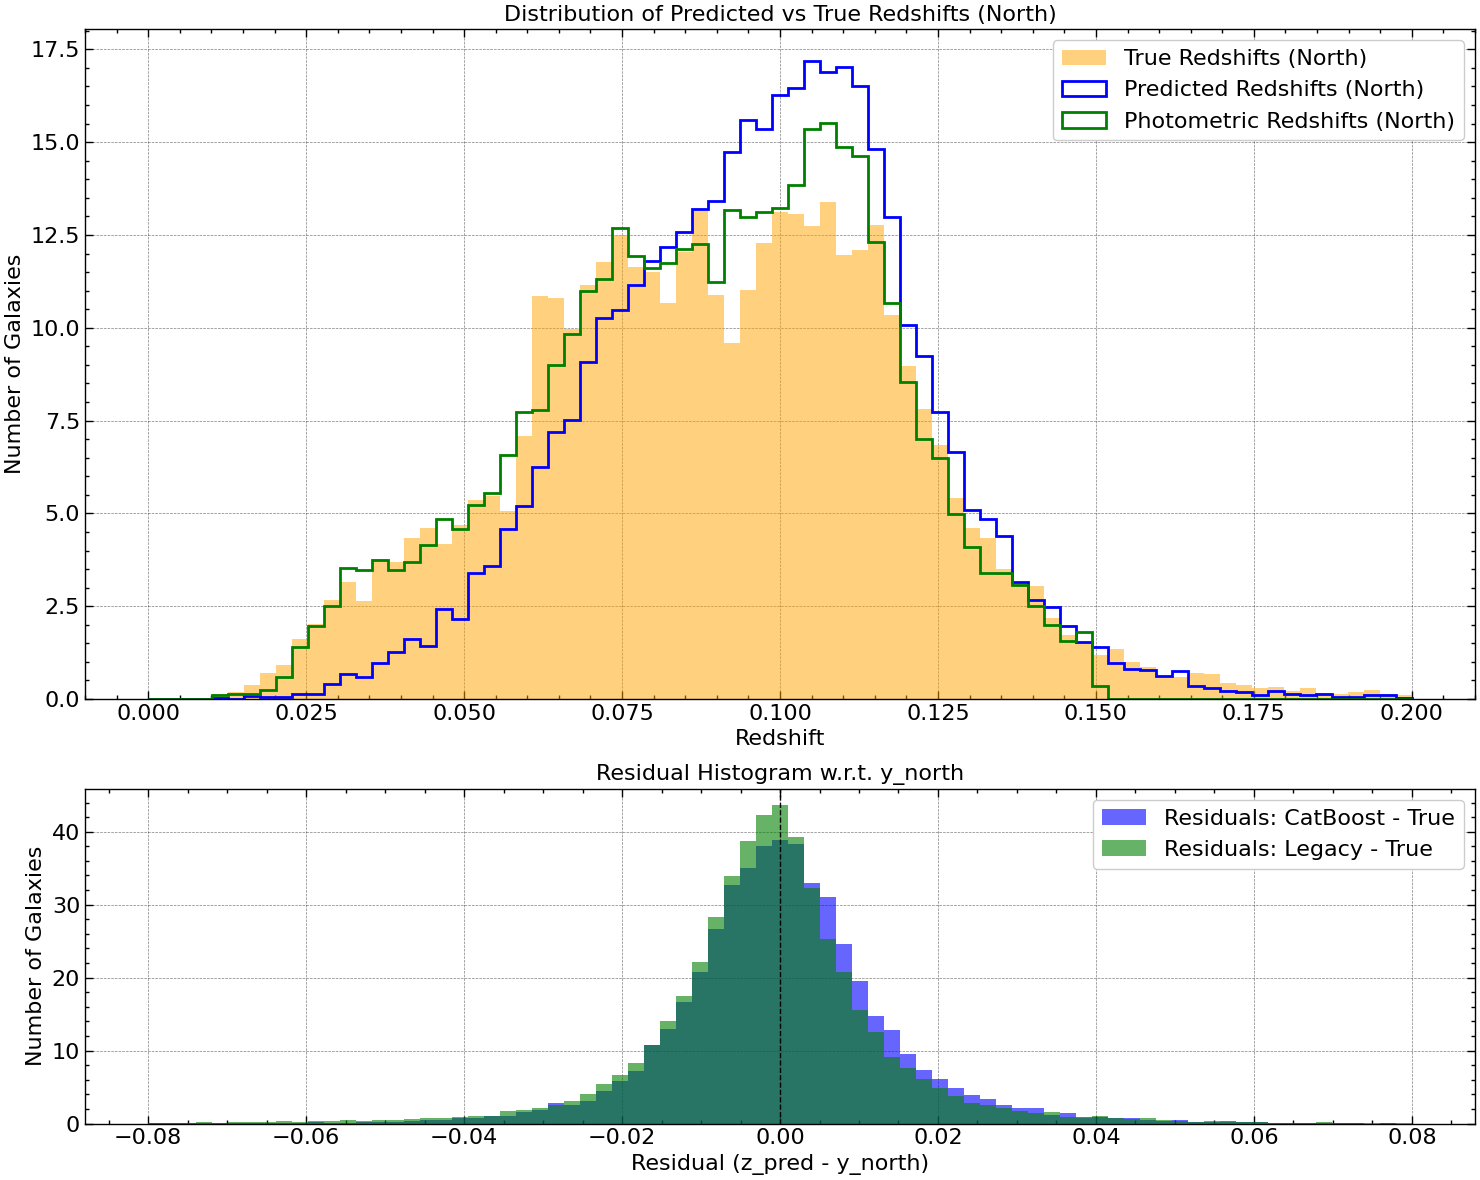

In [90]:
z_perturbed['median']

array([0.04800197, 0.1214872 , 0.04051147, ..., 0.09197323, 0.08266041,
       0.10546894], dtype=float32)

In [177]:
cfg =     PhotoZCatBoostPipeline.load_config('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_south/logs/config_used.yaml')
data_instance = PhotoZCatBoostPipeline(feature_names=cfg['features'])
matched_south = data_instance.compute_magnitudes(matched_south)
matched_south_photoz_filtered,  DR1_south_photoz_filtered= data_instance.filter_data(matched_south, matched_DR_south, feature_names =list(np.hstack([cfg['features'], 'Z_PHOT_MEDIAN'])))
matched_south_filtered, DR1_south_filtered = data_instance.filter_data(matched_south, matched_DR_south, feature_names = cfg['features'])
X_south, y_south = cv_pipe.prepare_ml_data(matched_south_filtered, DR1_south_filtered)
Z_pred_south = modelsouth.predict(X_south)
#z_perturbed = np.load('/user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_south/predictions/perturbed_predictions.npz')


INFO:catboost_cv:Config loaded from /user/animesh.sah/DESI_PECVEL/ML_photoz/runs/RUN2_south/logs/config_used.yaml
INFO:catboost_cv:Initialized PhotoZ pipeline using CPU
INFO:catboost_cv:Number of CPUs available: 32
INFO:catboost_cv:Computing magnitudes and colors...
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3', 'Z_PHOT_MEDIAN']
INFO:catboost_cv:Filtered from 95942 to 60893 objects
INFO:catboost_cv:Filtered from 95942 to 60893 objects for unique TARGETID
INFO:catboost_cv:Applying data quality cuts...
INFO:catboost_cv:Using features: ['MAG_R', 'MAG_G', 'MAG_GR', 'MAG_RZ', 'MAG_W1W2', 'MAG_ZW1', 'MAG_ZW2', 'R_CIRC', 'SHAPE_R', 'MODEL_WEIGHT', 'BBA', 'SERSIC', 'MAG_W1', 'MAG_W3', 'MAG_W1W3', 'MAG_RW2', 'MAG_GW1', 'MAG_GW3']
INFO:catboost_cv:Filtered from 95942 to 6089

Available Columns: ['BRICKID', 'BRICKNAME', 'OBJID', 'TYPE', 'RA', 'DEC', 'DCHISQ', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FLUX_W3', 'FLUX_W4', 'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2', 'FLUX_IVAR_W3', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'MW_TRANSMISSION_W3', 'MW_TRANSMISSION_W4', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'FRACFLUX_G', 'FRACFLUX_R', 'FRACFLUX_Z', 'FRACMASKED_G', 'FRACMASKED_R', 'FRACMASKED_Z', 'FRACIN_G', 'FRACIN_R', 'FRACIN_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'FIBERFLUX_G', 'FIBERFLUX_R', 'FIBERFLUX_Z', 'GAIA_PHOT_G_MEAN_MAG', 'MASKBITS', 'SERSIC', 'R_CIRC', 'MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'FIBERMAG_G', 'FIBERMAG_R', 'FIBERMAG_Z', 'MAG_NOEXT_G', 'MAG_NOEXT_R', 'MAG_NOEXT_Z', 'Z_PHOT_MEDIAN', 'Z_PHOT_L95', 'MAG_W2', 'MAG_W3', 'MAG_GR', 'MAG_RZ', 'MAG_GZ', 'MAG_W1W2', '

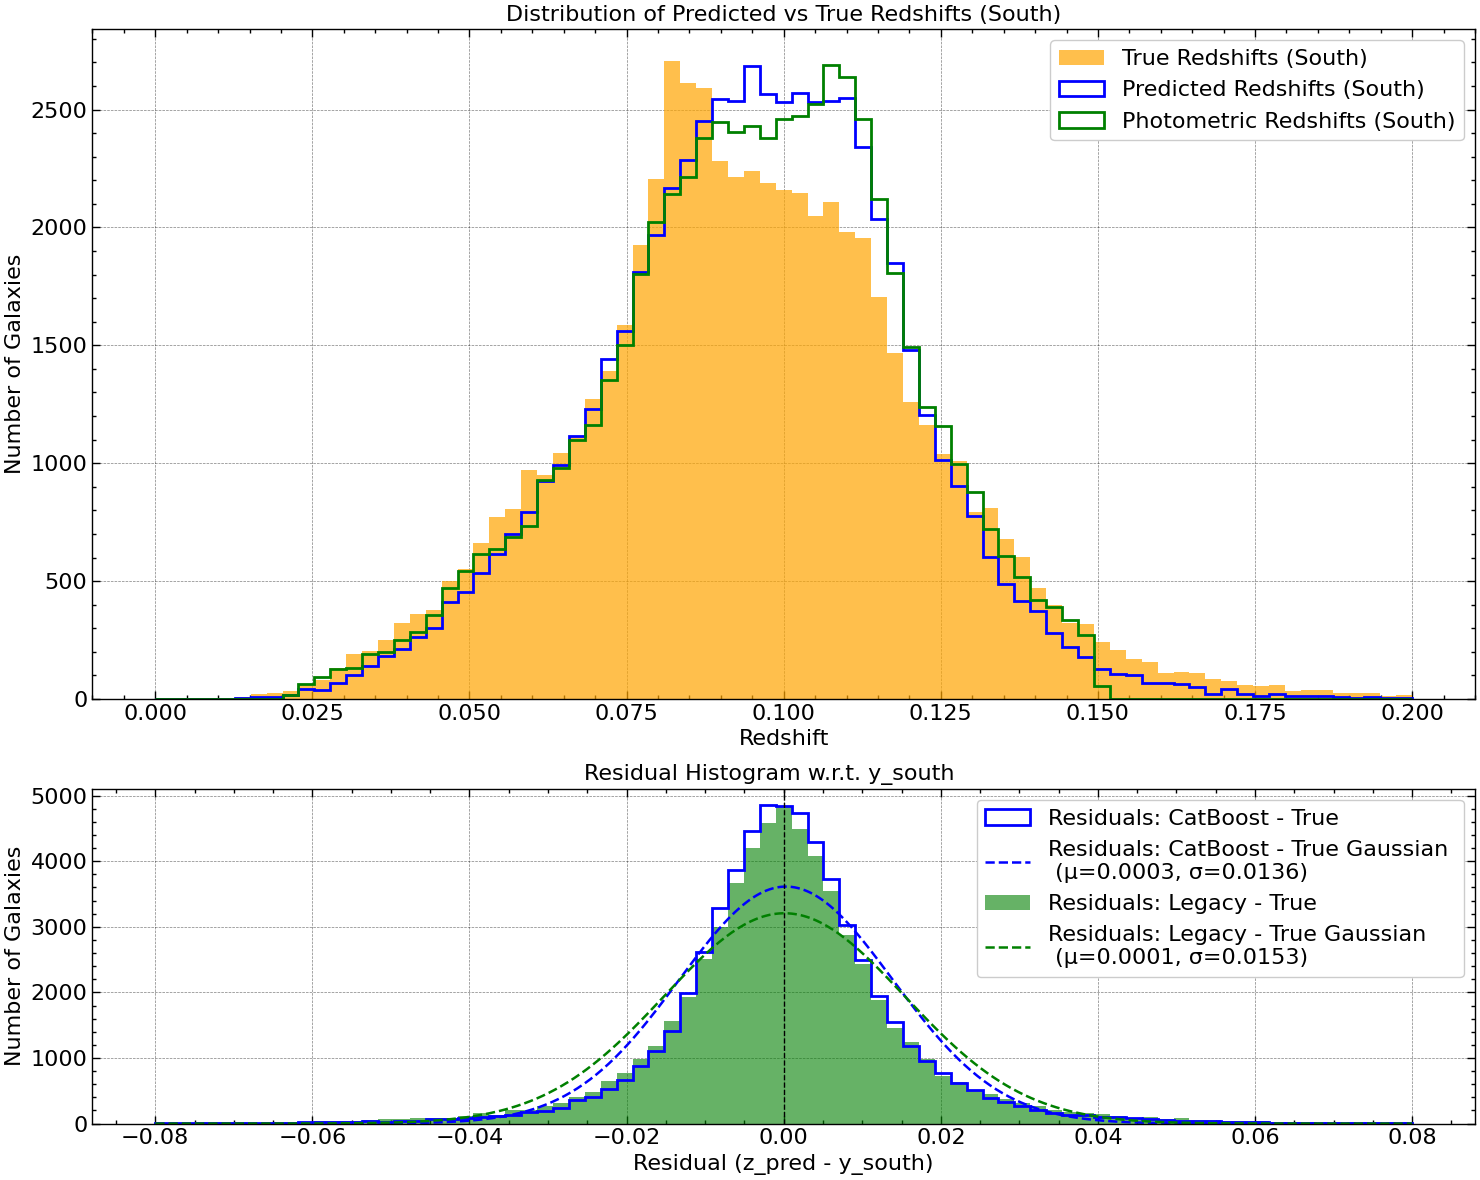

In [182]:
bins = np.linspace(0, 0.2, 80)
res_bins = np.linspace(-0.08, 0.08, 80)

legacy_photoz = np.asarray(matched_south_photoz_filtered['Z_PHOT_MEDIAN'])
valid_legacy = np.ones_like(legacy_photoz, dtype=bool) #np.isfinite(legacy_photoz) & (legacy_photoz > 0)

res_cb = Z_pred_south - y_south
res_legacy = legacy_photoz - y_south

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(15, 12), gridspec_kw={"height_ratios": [2, 1]}
)
ax0.hist(y_south, bins=bins, alpha=0.7, label='True Redshifts (South)', color='orange')

ax0.hist(Z_pred_south, bins=bins, histtype='step',lw=2, label='Predicted Redshifts (South)', color='blue')
#ax0.hist(z_perturbed['median'], bins=bins, histtype='step',lw=2, label='Perturbed Predictions (South)', color='red')
ax0.hist(legacy_photoz, bins=bins, histtype='step',lw=2, label='Photometric Redshifts (South)', color='green')
ax0.set_xlabel('Redshift')
ax0.set_ylabel('Number of Galaxies')
ax0.set_title('Distribution of Predicted vs True Redshifts (South)')
ax0.legend()

# res_perturbed = np.asarray(z_perturbed['median']) - DR1_south_filtered_perturbed['Z']

def _plot_residual_with_gaussian(ax, residuals, bins, color, label, **hist_kwargs):
    r = np.asarray(residuals)
    r = r[np.isfinite(r)]

    ax.hist(r, bins=bins, color=color, label=label, **hist_kwargs)

    # Fit Gaussian in the displayed residual range
    r_fit = r[(r >= bins[0]) & (r <= bins[-1])]
    if r_fit.size < 2:
        return

    mu = r_fit.mean()
    sigma = r_fit.std(ddof=1)
    if sigma <= 0:
        return

    x = np.linspace(bins[0], bins[-1], 400)
    bw = bins[1] - bins[0]
    y = r_fit.size * bw * np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    ax.plot(x, y, '--', color=color, lw=1.8, label=f'{label} Gaussian \n (μ={mu:.4f}, σ={sigma:.4f})')

_plot_residual_with_gaussian(ax1, res_cb, res_bins, 'blue',  'Residuals: CatBoost - True', histtype='step', lw=2)
_plot_residual_with_gaussian(ax1, res_legacy, res_bins, 'green', 'Residuals: Legacy - True', alpha=0.6)
#_plot_residual_with_gaussian(ax1, res_perturbed, res_bins, 'red', 'Residuals: Perturbed - True', histtype='step', lw=2)
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Residual (z_pred - y_south)')
ax1.set_ylabel('Number of Galaxies')
ax1.set_title('Residual Histogram w.r.t. y_south    ')
ax1.legend()

plt.tight_layout()
plt.show()

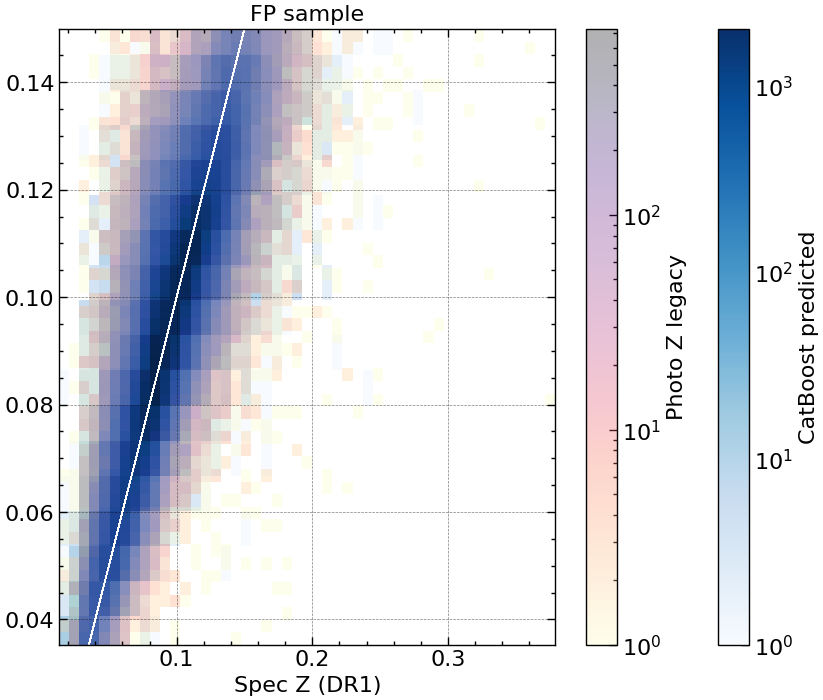

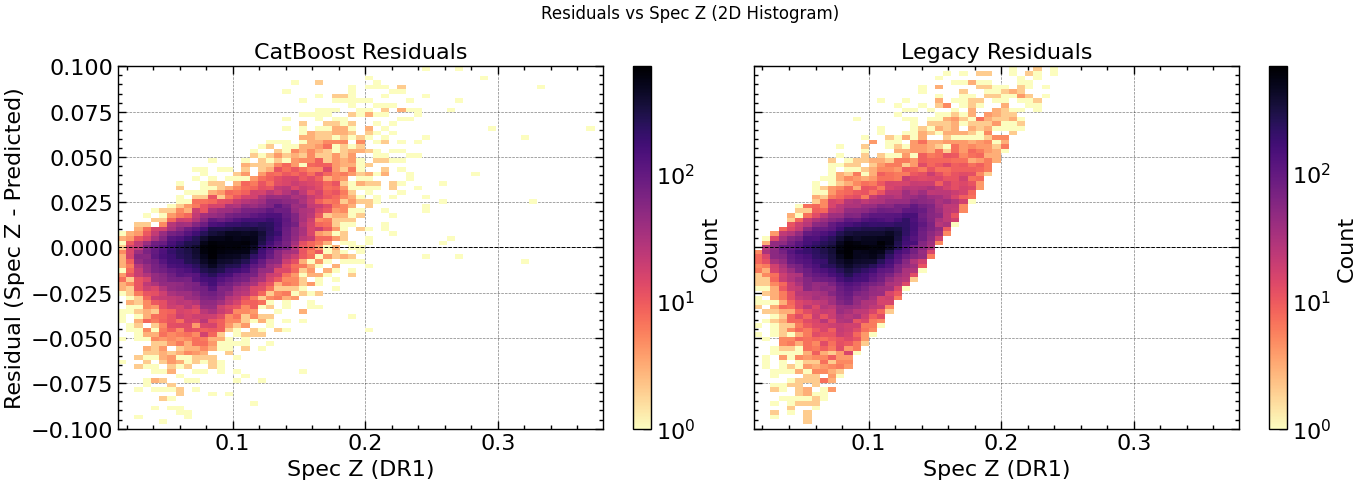

In [217]:
from matplotlib.colors import LogNorm

binx = np.linspace(min(y_south), 
                    max(y_south), 50)
biny = np.linspace(min(Z_pred_south), 
                    max(Z_pred_south), 50)
hist, xedges, yedges = np.histogram2d(y_south, 
                                        Z_pred_south, 
                                        bins=(binx, biny))

# Log scale plot
plt.figure(figsize=(10, 8))
plt.imshow(hist.T, origin='lower',
            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
            aspect='auto', cmap='Blues', norm=LogNorm())
plt.plot(Z_pred_south, Z_pred_south, 'w--', lw=0.7)
plt.colorbar(label = 'CatBoost predicted')
plt.title('FP sample')
plt.xlabel('Z (DR1)')


biny = np.linspace(np.percentile(legacy_photoz, 1), max(legacy_photoz), 50)
binx = np.linspace(min(y_south), max(y_south), 50)
hist,xedges,yedges=np.histogram2d(y_south, legacy_photoz, bins=(binx, biny))
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm(),alpha=0.3)

#plt.plot(legacy_photoz,legacy_photoz,'k--',lw=0.7)
plt.colorbar(label = 'Photo Z legacy')
plt.xlabel('Spec Z (DR1)')
plt.show()
res_catboost = y_south - Z_pred_south
res_legacy = y_south - legacy_photoz

x_bins = np.linspace(np.min(y_south), np.max(y_south), 60)
y_bins = np.linspace(-0.1, 0.1, 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

h_cb = axes[0].hist2d(
    y_south, res_catboost,
    bins=[x_bins, y_bins],
    cmap='magma_r',
    norm=LogNorm(),
    cmin=1
)
axes[0].axhline(0, color='black', linestyle='--', lw=0.7)
axes[0].set_title('CatBoost Residuals')
axes[0].set_xlabel('Spec Z (DR1)')
axes[0].set_ylabel('Residual (Spec Z - Predicted)')
fig.colorbar(h_cb[3], ax=axes[0], label='Count')

h_lg = axes[1].hist2d(
    y_south, res_legacy,
    bins=[x_bins, y_bins],
    cmap='magma_r',
    norm=LogNorm(),
    cmin=1
)
axes[1].axhline(0, color='black', linestyle='--', lw=0.7)
axes[1].set_title('Legacy Residuals')
axes[1].set_xlabel('Spec Z (DR1)')
fig.colorbar(h_lg[3], ax=axes[1], label='Count')

plt.suptitle('Residuals vs Spec Z (2D Histogram)')
plt.tight_layout()
plt.show()



In [200]:
res_legacy

array([ 0.01613253,  0.00532077,  0.00811154, ...,  0.00102767,
       -0.01043496,  0.02908015], dtype=float32)

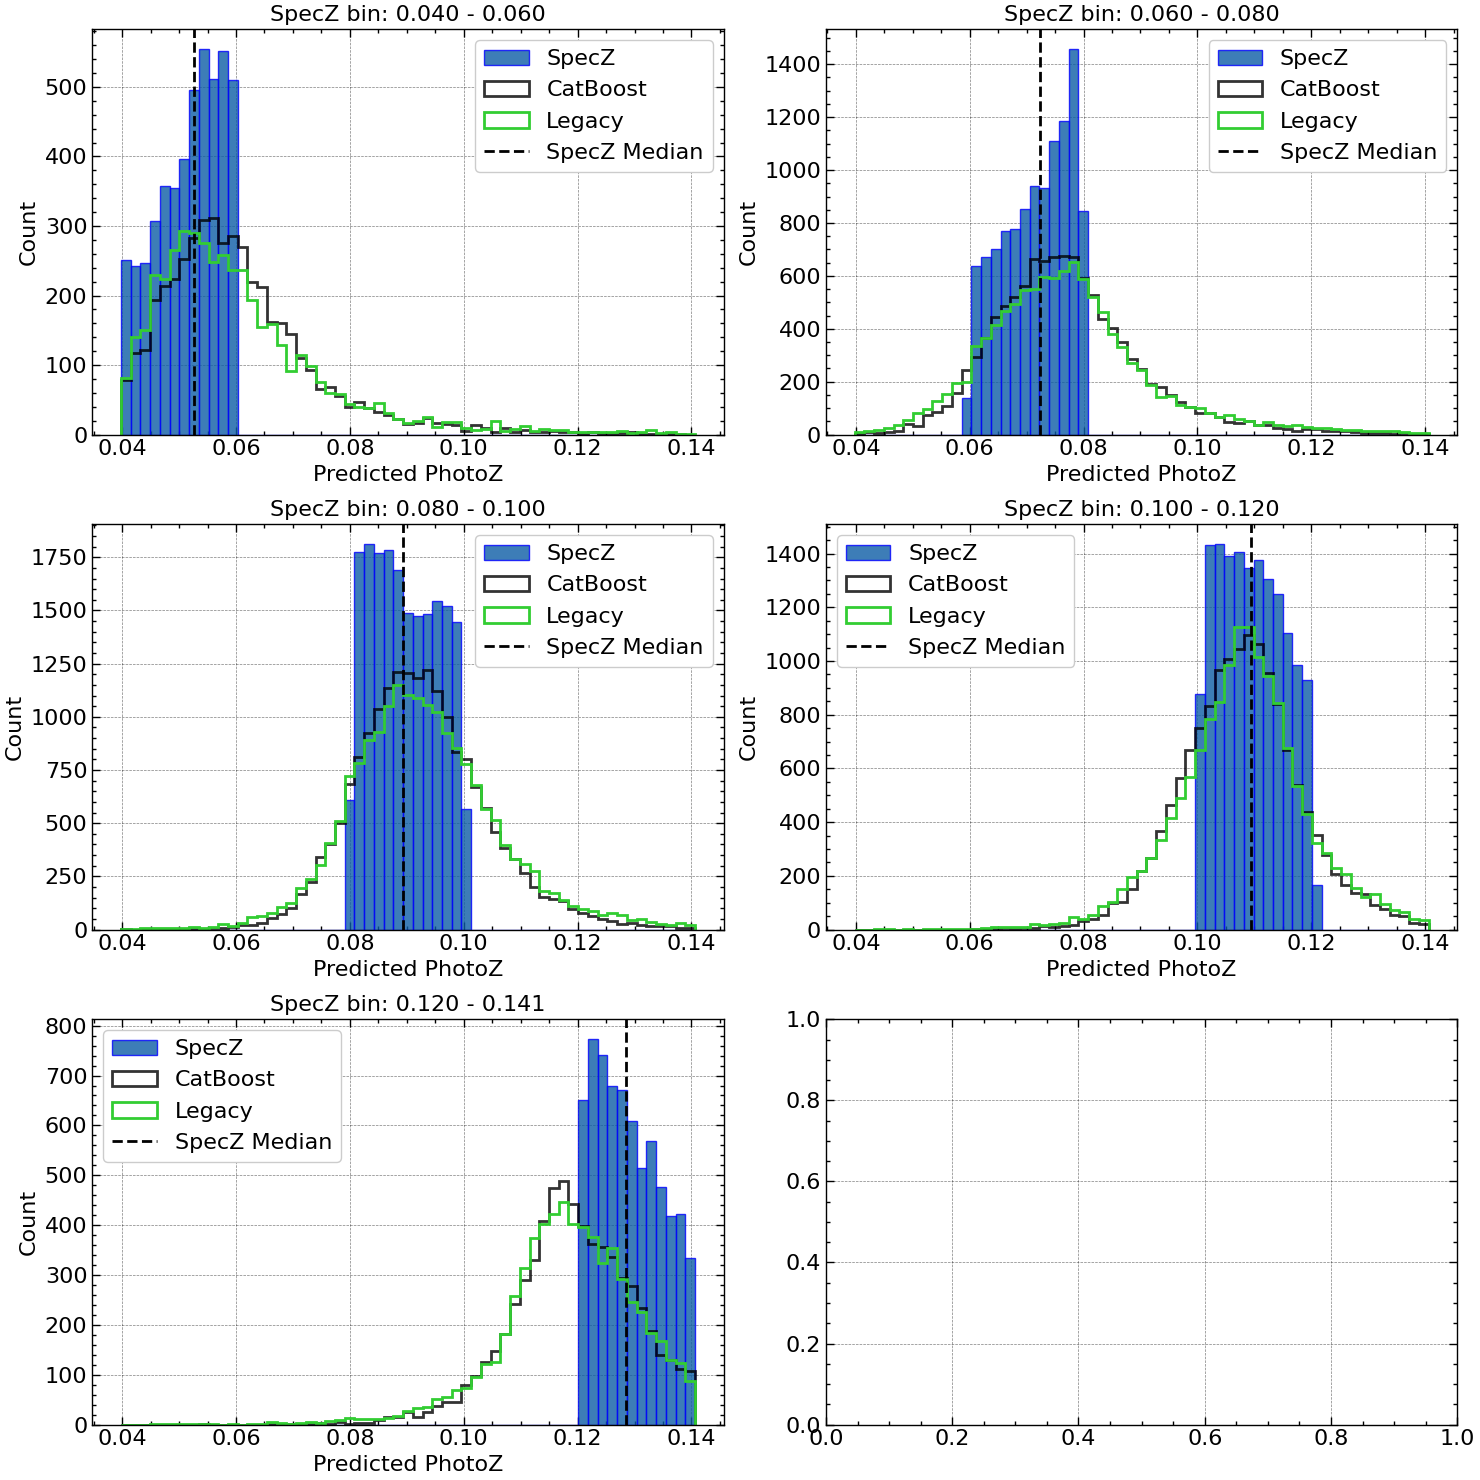

In [181]:
nbins = 5 
zbins = np.linspace(np.percentile(DR1_south_filtered['Z'], 2), np.percentile(DR1_south_filtered['Z'], 95), nbins+1)
bin_indices = np.digitize(DR1_south_filtered['Z'], zbins)
#bin_indices_perturbed = np.digitize(DR1_south_filtered_perturbed['Z'], zbins)
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()
for i in range(1, nbins+1):
    mask = bin_indices == i
    mask_perturbed = bin_indices_perturbed == i
    phot_z_bin  =Z_pred_south[mask]
    spec_z_bin = DR1_south_filtered['Z'][mask]
    phot_z_legacy_bin = matched_south_photoz_filtered['Z_PHOT_MEDIAN'][mask]
    #phot_z_perturbed_bin = z_perturbed['median'][mask_perturbed]
    bin_hist = np.linspace(zbins[0],zbins[-1],60)
    axes[i-1].hist(spec_z_bin,bins =bin_hist ,alpha =0.8, label='SpecZ',edgecolor='blue')
    axes[i-1].hist(phot_z_bin,bins =bin_hist ,alpha =0.8, label='CatBoost',histtype='step',edgecolor='k',lw = 2)
    axes[i-1].hist(phot_z_legacy_bin,bins =bin_hist ,alpha =1, label='Legacy',histtype='step',edgecolor='limegreen',lw =2)
    #axes[i-1].hist(phot_z_perturbed_bin,bins =bin_hist ,alpha =0.8, label='Perturbed',histtype='step',edgecolor='red',lw =2,ls='--')
    axes[i-1].axvline(np.median(spec_z_bin), color='k', linestyle='--', label='SpecZ Median')
    axes[i-1].set_title(f'SpecZ bin: {zbins[i-1]:.3f} - {zbins[i]:.3f}')
    axes[i-1].legend()
    axes[i-1].set_xlabel('Predicted PhotoZ')
    axes[i-1].set_ylabel('Count')   
plt.tight_layout()
plt.show()